# Bayesian GMM — Block Bootstrap (pmr_paper)

Distribution of active regime counts on resampled `data/features.csv`.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler


def _find_pmr_root() -> Path:
    """Locate pmr_paper/ from the notebook working directory."""
    start = Path.cwd().resolve()
    for parent in [start, *start.parents]:
        if (parent / "scripts" / "paths.py").is_file():
            return parent
    raise FileNotFoundError(
        "Could not locate pmr_paper (scripts/paths.py not found). "
        "Run this notebook from inside the pmr_paper tree."
    )


PROJECT_ROOT = _find_pmr_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.paths import FEATURES_PATH, load_features

features = load_features()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features.values)

print(f"Project root: {PROJECT_ROOT}")
print(f"Features: {FEATURES_PATH}")
print(f"Shape after cleaning: {features.shape}")


from scripts.bootstrap import run_bayesian_bootstrap


Project root: /Users/antoinea/Desktop/Master_Thesis
Features: /Users/antoinea/Desktop/Master_Thesis/data/features.csv
Shape after cleaning: (663, 17)


In [2]:
# Bootstrap settings
N_ITER = 3000
BLOCK_SIZE = 120
MAX_COMPONENTS = 10
WEIGHT_THRESHOLD = 0.05
ALPHA_PRIOR = 0.1
N_JOBS = -1

bootstrap_k = run_bayesian_bootstrap(
    data=X_scaled,
    n_iterations=N_ITER,
    block_size=BLOCK_SIZE,
    max_components=MAX_COMPONENTS,
    threshold=WEIGHT_THRESHOLD,
    alpha=ALPHA_PRIOR,
    n_jobs=N_JOBS,
)

bootstrap_k = np.array(bootstrap_k)
bootstrap_k[:10]

Starting 3000 bootstrap iterations (Block Size: 120 months)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1896469943112886s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done  84 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 144 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done 178 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 212 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: 

array([6, 4, 2, 5, 4, 6, 6, 5, 4, 5])

In [3]:
summary = pd.Series(bootstrap_k).value_counts().sort_index().rename("Count").to_frame()
summary["Frequency"] = summary["Count"] / len(bootstrap_k)
summary.index.name = "Active_Regimes"
summary

,Count,Frequency
Active_Regimes,,
2,95,0.031667
3,387,0.129000
4,595,0.198333
5,686,0.228667
6,695,0.231667
7,398,0.132667
8,130,0.043333
9,14,0.004667


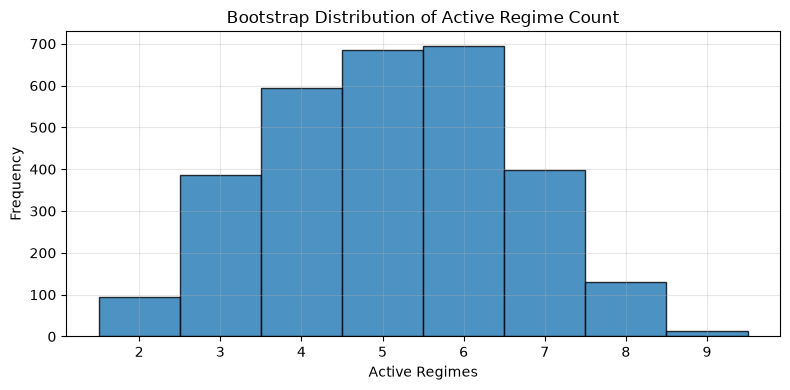

Mean active regimes: 5.09
Median active regimes: 5
Std active regimes: 1.49


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
vals = pd.Series(bootstrap_k)
ax.hist(vals, bins=np.arange(vals.min() - 0.5, vals.max() + 1.5, 1), edgecolor="black", alpha=0.8)
ax.set_title("Bootstrap Distribution of Active Regime Count")
ax.set_xlabel("Active Regimes")
ax.set_ylabel("Frequency")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean active regimes: {vals.mean():.2f}")
print(f"Median active regimes: {vals.median():.0f}")
print(f"Std active regimes: {vals.std(ddof=1):.2f}")